In [64]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [65]:
df = pd.read_csv('TestAnomalyUnlabled.csv')
df.head()

,timestamp,temperature_c,humidity_pct,pressure_hpa
0,2026-08-01 08:00:00,29.054849,67.952574,1007.841817
1,2026-08-01 08:01:00,28.852943,67.316221,1007.782302
2,2026-08-01 08:02:00,29.215345,67.467761,1008.182620
3,2026-08-01 08:03:00,29.289658,68.206237,1008.134222
4,2026-08-01 08:04:00,28.809215,67.601390,1007.569751


In [66]:
anomaly_inputs = ["temperature_c","humidity_pct","pressure_hpa"]
model_IF = IsolationForest(contamination='auto')

In [67]:
model_IF.fit(df[anomaly_inputs])

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ax_features=1)


In [68]:
df['anomaly_scores'] = model_IF.decision_function(df[anomaly_inputs])
df['anomaly'] = model_IF.predict(df[anomaly_inputs])

In [69]:
df.loc[:,["temperature_c","humidity_pct","pressure_hpa","anomaly_scores","anomaly"]]

,temperature_c,humidity_pct,pressure_hpa,anomaly_scores,anomaly
0,29.054849,67.952574,1007.841817,0.054672,1
1,28.852943,67.316221,1007.782302,0.054510,1
2,29.215345,67.467761,1008.182620,0.074107,1
3,29.289658,68.206237,1008.134222,0.059181,1
4,28.809215,67.601390,1007.569751,0.048828,1
...,...,...,...,...,...
995,31.184471,63.011156,1009.086194,0.110865,1
996,31.257329,62.944818,1008.943007,0.099328,1
997,31.138877,62.634105,1010.194387,0.095129,1
998,31.137804,62.289677,1009.677271,0.096117,1


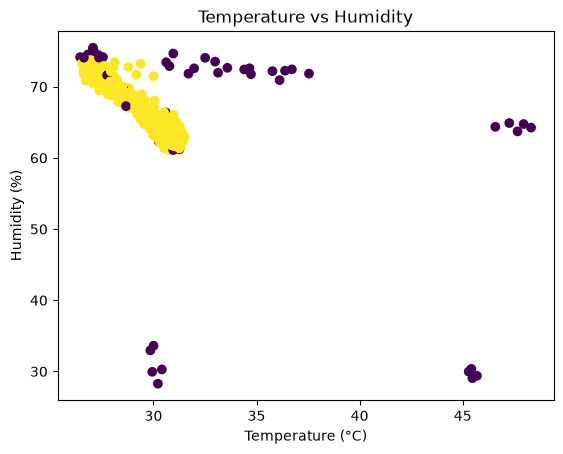

In [70]:
plt.scatter(
    df["temperature_c"],
    df["humidity_pct"],
    c=df["anomaly"]
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.title("Temperature vs Humidity")
plt.show()

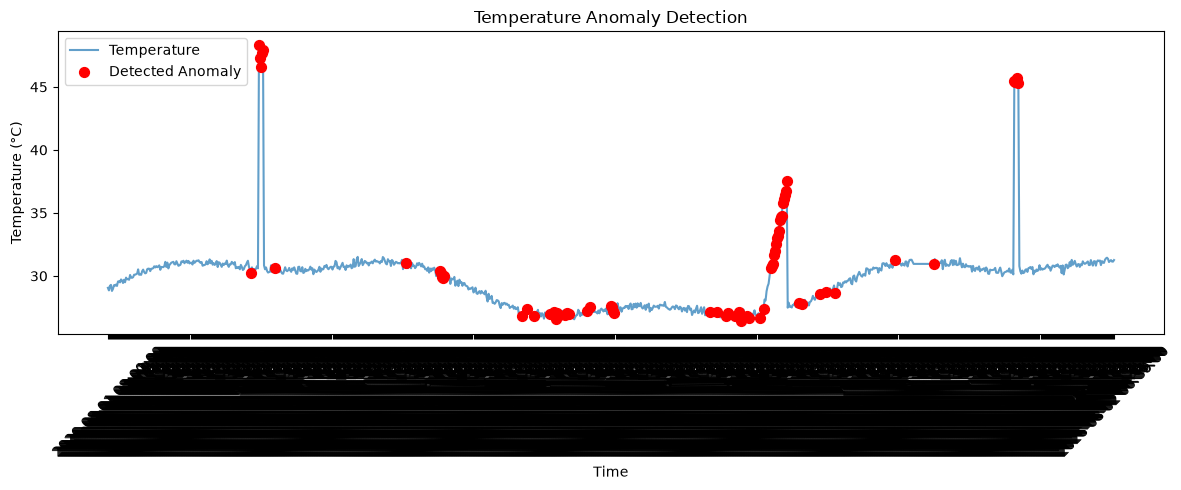

In [71]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["timestamp"],
    df["temperature_c"],
    label="Temperature",
    alpha=0.7
)
anomalies = df[df["anomaly"] == -1]

plt.scatter(
    anomalies["timestamp"],
    anomalies["temperature_c"],
    color="red",
    label="Detected Anomaly",
    s=50,
    zorder=3
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Anomaly Detection")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

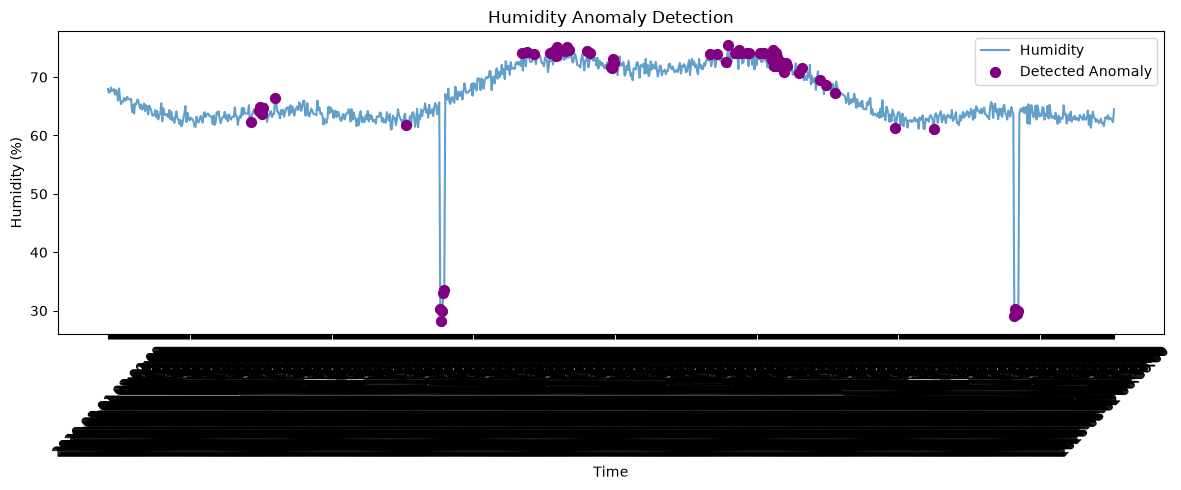

In [72]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["timestamp"],
    df["humidity_pct"],
    label="Humidity",
    alpha=0.7
)
anomalies = df[df["anomaly"] == -1]

plt.scatter(
    anomalies["timestamp"],
    anomalies["humidity_pct"],
    color="purple",
    label="Detected Anomaly",
    s=50,
    zorder=3
)

plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.title("Humidity Anomaly Detection")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

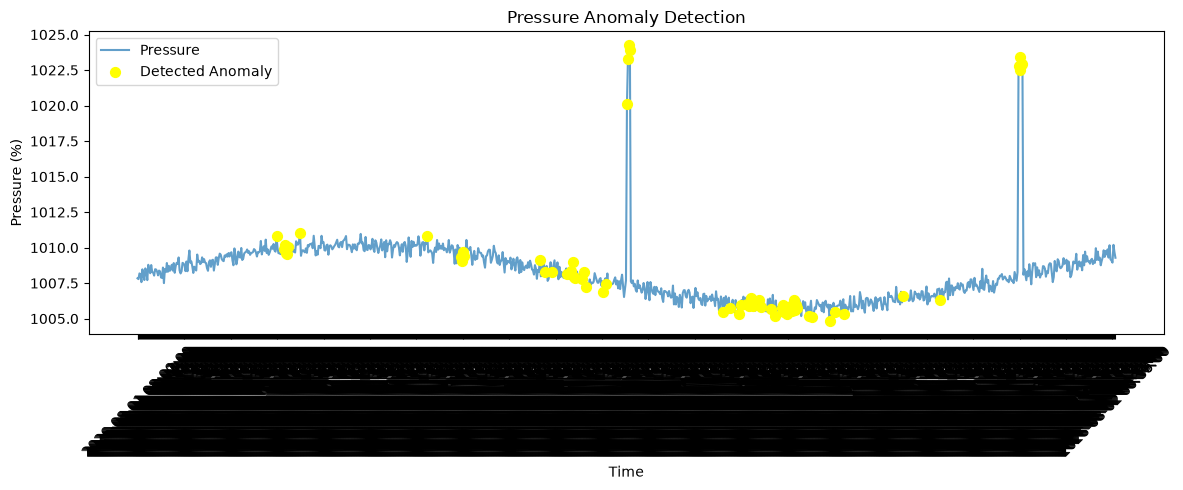

In [73]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["timestamp"],
    df["pressure_hpa"],
    label="Pressure",
    alpha=0.7
)
anomalies = df[df["anomaly"] == -1]

plt.scatter(
    anomalies["timestamp"],
    anomalies["pressure_hpa"],
    color="yellow",
    label="Detected Anomaly",
    s=50,
    zorder=3
)

plt.xlabel("Time")
plt.ylabel("Pressure (%)")
plt.title("Pressure Anomaly Detection")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()